<a href="https://colab.research.google.com/github/andrealoy/PathMNISTClassification/blob/main/pathmnist_classification_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA

In [48]:
!pip install medmnist

In [49]:
!git clone https://github.com/andrealoy/PathMNISTClassification.git

Cloning into 'PathMNISTClassification'...
remote: Enumerating objects: 27, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 27 (delta 11), reused 19 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (27/27), 1.96 MiB | 11.43 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [50]:
%cd PathMNISTClassification

/content/PathMNISTClassification/PathMNISTClassification


In [51]:
%cd /content/PathMNISTClassification

/content/PathMNISTClassification


In [52]:
#%load_ext autoreload
#%autoreload 2
import medmnist
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from utils import *
from medmnist import PathMNIST,INFO
from pathlib import Path
from tqdm import tqdm

In [53]:
ROOT_DIR = "./data"
# Create the directory if it doesn't exist
Path(ROOT_DIR).mkdir(parents=True, exist_ok=True)
SEED = 42
IMG_SIZE = (28, 28)
HIDDEN_SIZE = 256
CHANNELS = 3
NUM_CLASSES = 9
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3

In [54]:
# Activation de la seed pour rendre l'entraînement reproductible
# (initialisation des poids, shuffle des batches, etc.)

import random
import numpy as np

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [57]:
dataset = PathMNIST(root=ROOT_DIR, split="train", download=True)

In [58]:
# Load PathMNIST info
data_flag = 'pathmnist'
info = INFO[data_flag]
DataClass = getattr(medmnist, info['python_class'])

In [59]:
info

{'python_class': 'PathMNIST',
 'description': 'The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K into training and validation set with a ratio of 9:1. The CRC-VAL-HE-7K is treated as the test set.',
 'url': 'https://zenodo.org/records/10519652/files/pathmnist.npz?download=1',
 'MD5': 'a8b06965200029087d5bd730944a56c1',
 'url_64': 'https://zenodo.org/records/10519652/files/pathmnist_64.npz?download=1',
 'MD5_64': '55aa9c1e0525abe5a6b9d8343a507616',
 'url_128': 'https://zenodo.org/records/10519652/files/pathmnist_128.npz?download=1',
 'MD5

In [60]:
print(f"Number of samples: {len(dataset)}")

Number of samples: 89996


In [61]:
for key, value in dataset.info['label'].items():
    print(f"Class {key} : {value}")

Class 0 : adipose
Class 1 : background
Class 2 : debris
Class 3 : lymphocytes
Class 4 : mucus
Class 5 : smooth muscle
Class 6 : normal colon mucosa
Class 7 : cancer-associated stroma
Class 8 : colorectal adenocarcinoma epithelium


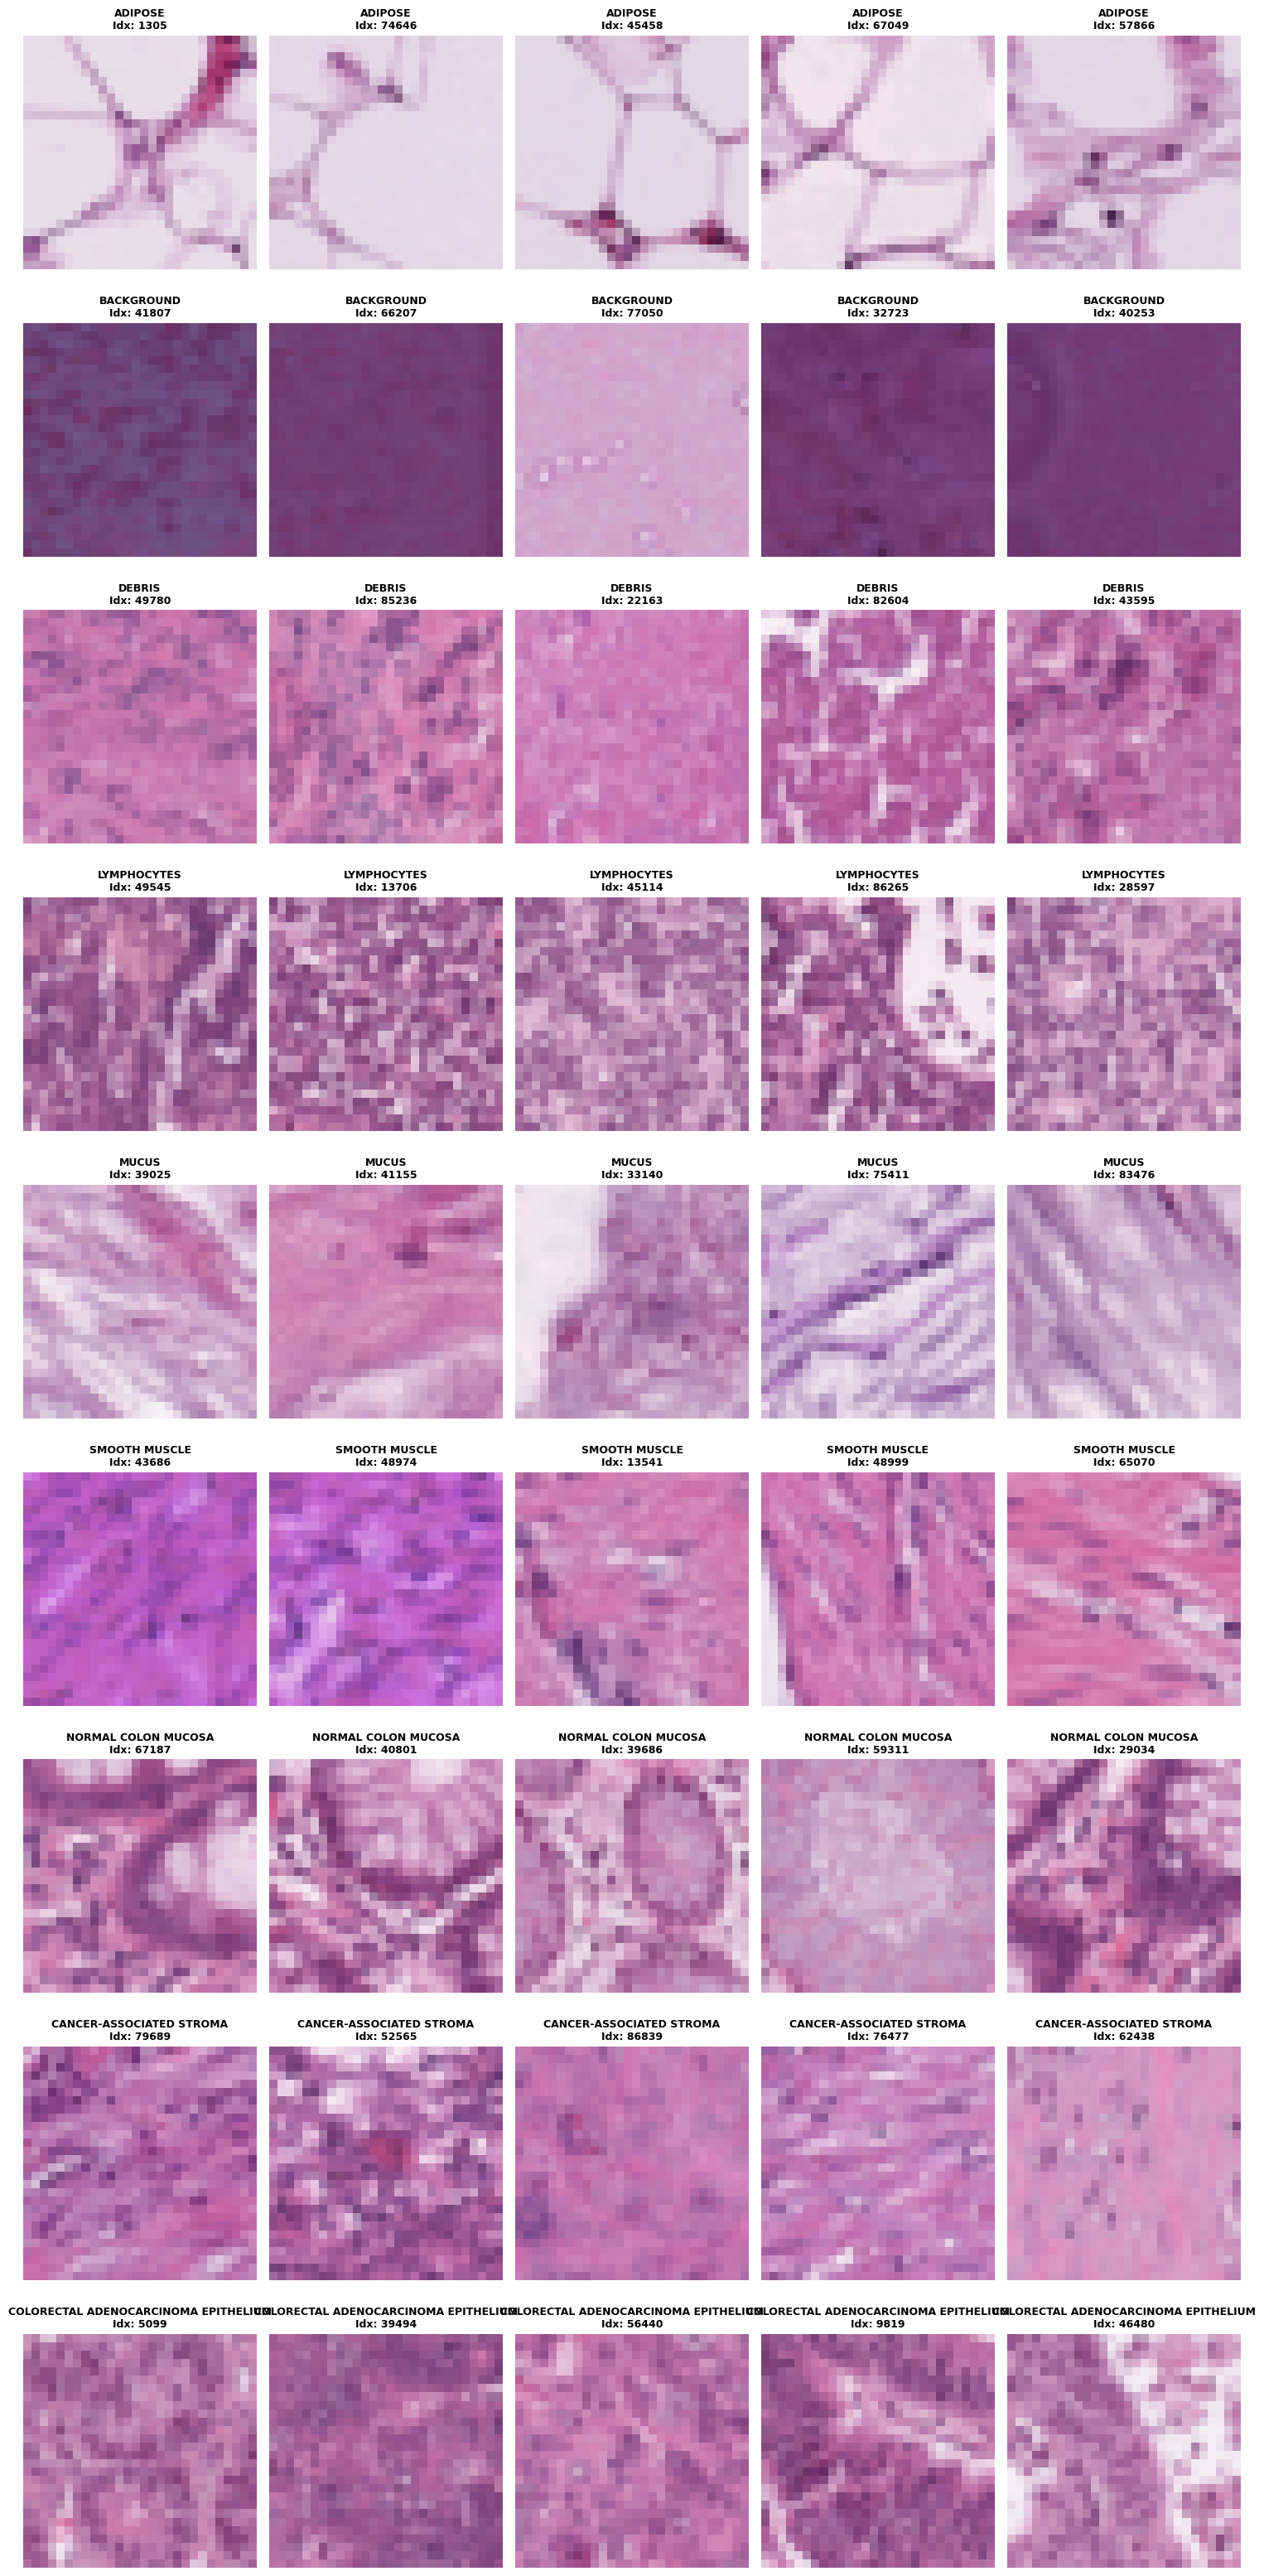

In [ ]:
display_medmnist_samples(dataset,"*",5)

En observant plusieurs images de la classe Debris et en les comparant avec celles de la classe Background, on remarque des différences visuelles nettes.

Les images de la classe Debris présentent généralement des fragments irréguliers et des structures plus hétérogènes. On y observe souvent une texture plus complexe, avec des amas de formes ou des contours marqués qui se détachent du reste de l’image. Les couleurs peuvent aussi varier davantage, avec des zones plus sombres ou plus denses.

À l’inverse, les images de la classe Background apparaissent plus uniformes et plus lisses. La texture est généralement plus homogène, avec peu de structures distinctes ou de contours marqués. Les couleurs sont aussi plus régulières, souvent dominées par des tons rosés ou violacés relativement constants.

Ainsi, les images Debris se caractérisent par des textures irrégulières et des motifs plus complexes, tandis que les images Background sont plus homogènes et moins structurées visuellement.

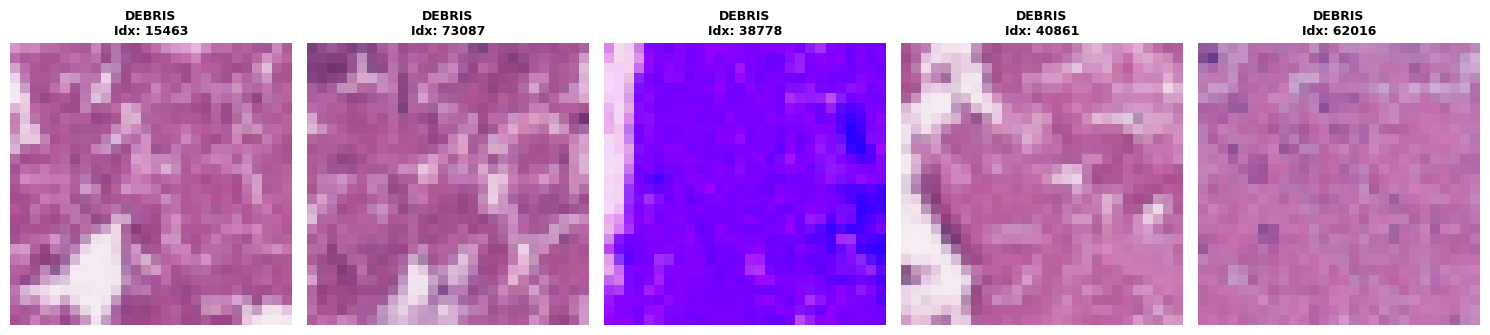

In [ ]:
display_medmnist_samples(dataset,"debris",5)

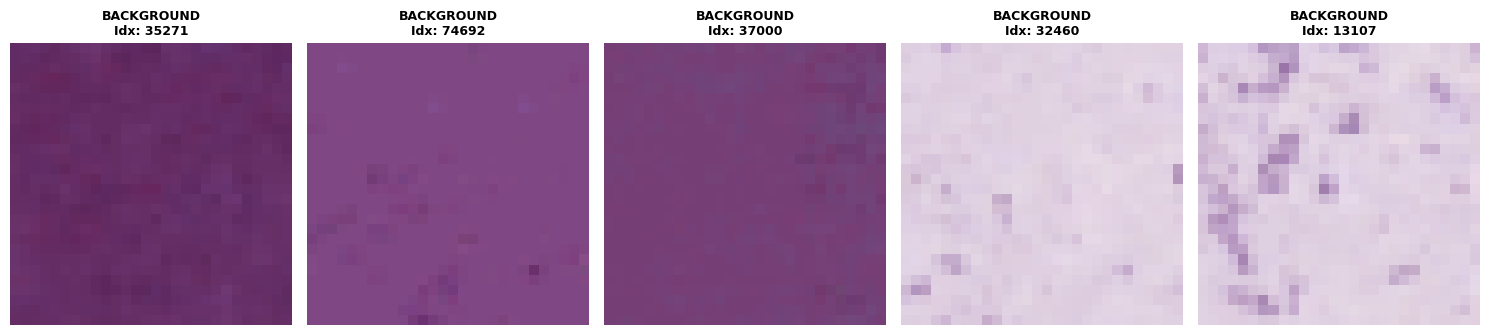

In [ ]:
display_medmnist_samples(dataset,"background",5)

In [ ]:
print_dataset_structure(dataset)

--- Dataset Structure: PATHMNIST ---
Total samples: 89996
Image shape: (89996, 28, 28, 3)
Labels shape: (89996, 1)
Mode: RGB


In [ ]:
plot_class_distribution(dataset)

--- Pixel Stats: Mean=168.25, Std=43.36, Min=0, Max=255 ---


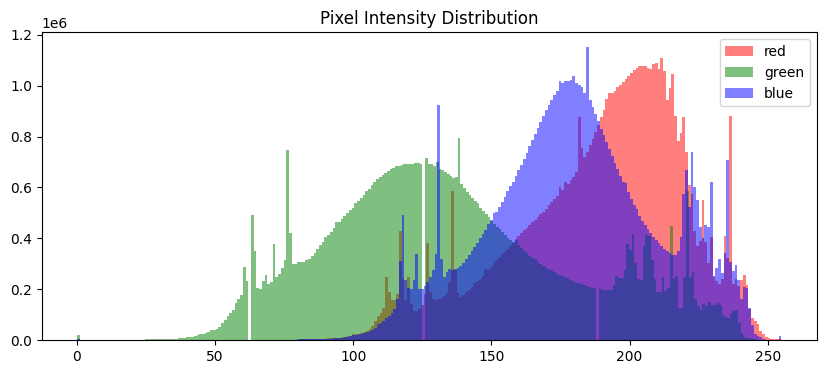

In [ ]:
show_pixel_stats(dataset)

--- Stats for Image Index: 15795 (Seed: 42) ---
Shape: (28, 28, 3)
Red   Channel -> Mean: 128.48 | Std: 10.92
Green Channel -> Mean: 71.84 | Std: 7.18
Blue  Channel -> Mean: 125.65 | Std: 9.77
Global Stats -> Min: 11 | Max: 139


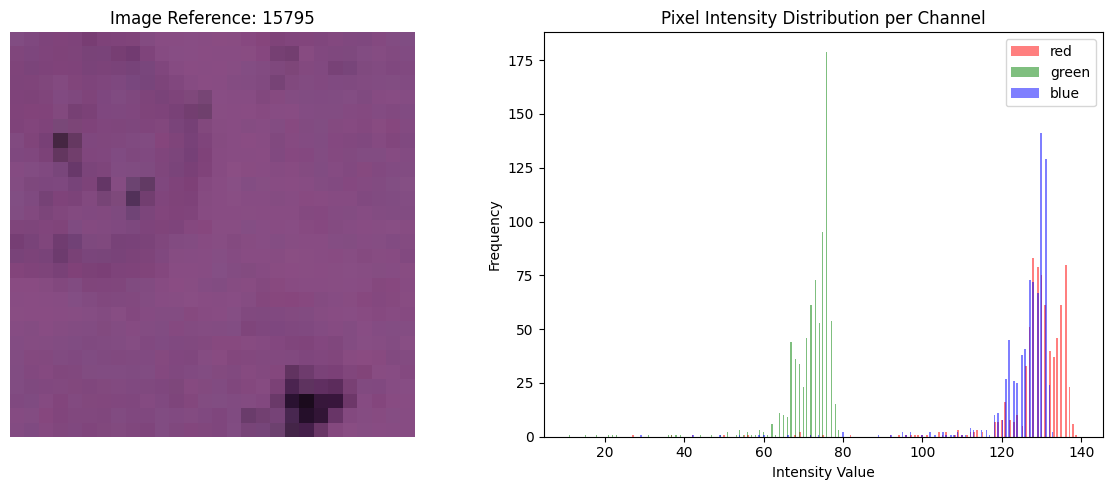

In [ ]:
show_random_pixel_stats(dataset)

Nous avons calculé la moyenne et l’écart-type des intensités de pixels pour chaque canal RGB sur une image du jeu d’entraînement. Les valeurs obtenues sont différentes des statistiques d’ImageNet. Cela est attendu car les images du dataset PathMNIST sont des images histopathologiques avec des distributions de couleurs spécifiques (principalement des teintes roses et violettes dues à la coloration H&E), tandis qu’ImageNet contient des images naturelles avec une distribution de couleurs plus variée. Les statistiques de pixels ne sont donc pas proches de celles d’ImageNet.

+ nos pixels sont normalisés entre -1 et 1

alors que ImageNet est normalisé autour de 0-1 puis standardisé

# Preparing the data

In [62]:
# Simple Preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [63]:
# 2. Load the 3 splits (it only downloads once!)
train_dataset = PathMNIST(root=ROOT_DIR, split="train", transform=transform, download=False)
val_dataset   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform, download=False)
test_dataset  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform, download=False)

# 3. Create your loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# MLP

In [64]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes, dropout_prob=0.5):
        super(MLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, num_classes)

        self.dropout = nn.Dropout(dropout_prob)

    def forward(self, x):
        # Flatten the input
        x = x.view(x.size(0), -1)
        # First hidden layer + ReLU + Dropout
        x = F.relu(self.fc1(x))
        x = self.dropout(x)

        # Second hidden layer + ReLU + Dropout
        x = F.relu(self.fc2(x))
        x = self.dropout(x)

        # Output layer
        x = self.fc3(x)
        return x


In [65]:
baseline = MLP(input_size=IMG_SIZE[0] * IMG_SIZE[1] * CHANNELS, hidden_size=HIDDEN_SIZE, num_classes=NUM_CLASSES)

In [66]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
baseline = baseline.to(device)
print(baseline)

MLP(
  (fc1): Linear(in_features=2352, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=9, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [67]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(baseline.parameters(), lr=LEARNING_RATE)

Training loop

In [ ]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()

            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE (Required for Q2.1) ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)

        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [ ]:
history = train_and_evaluate(baseline, train_loader, val_loader, criterion, optimizer, EPOCHS, device)

Epoch 1/10: 100%|██████████| 704/704 [00:22<00:00, 31.08it/s, loss=1.36]


Summary Epoch 1: Val Loss: 1.3368 | Val Acc: 49.67%


Epoch 2/10: 100%|██████████| 704/704 [00:21<00:00, 32.19it/s, loss=1.27]


Summary Epoch 2: Val Loss: 1.2669 | Val Acc: 52.81%


Epoch 3/10: 100%|██████████| 704/704 [00:21<00:00, 32.13it/s, loss=1.5]


...

Summary Epoch 8: Val Loss: 1.3027 | Val Acc: 50.42%


Epoch 9/10: 100%|██████████| 704/704 [00:22<00:00, 31.84it/s, loss=1.09]


Summary Epoch 9: Val Loss: 1.2999 | Val Acc: 51.15%


Epoch 10/10: 100%|██████████| 704/704 [00:21<00:00, 32.24it/s, loss=1.54]


Summary Epoch 10: Val Loss: 1.3090 | Val Acc: 52.02%


Test accuracy: 0.13454539458880674


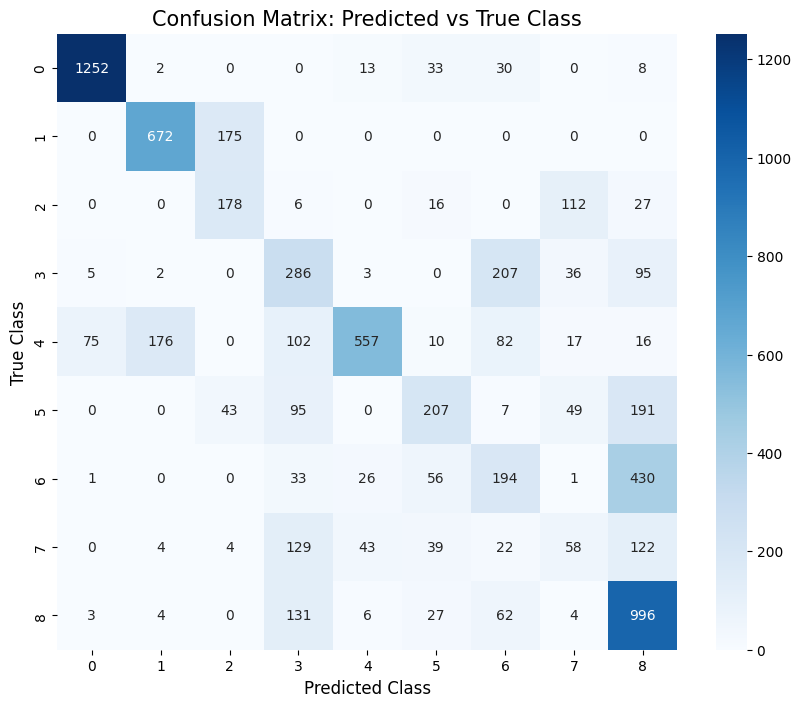

array([[1252,    2,    0,    0,   13,   33,   30,    0,    8],
       [   0,  672,  175,    0,    0,    0,    0,    0,    0],
       [   0,    0,  178,    6,    0,   16,    0,  112,   27],
       [   5,    2,    0,  286,    3,    0,  207,   36,   95],
       [  75,  176,    0,  102,  557,   10,   82,   17,   16],
       [   0,    0,   43,   95,    0,  207,    7,   49,  191],
       [   1,    0,    0,   33,   26,   56,  194,    1,  430],
       [   0,    4,    4,  129,   43,   39,   22,   58,  122],
       [   3,    4,    0,  131,    6,   27,   62,    4,  996]])

In [ ]:
# Évaluation sur l'ensemble de test (exigence de l'énoncé)
# La boucle d'entraînement affiche les métriques train/validation.
# Cette cellule calcule la performance finale sur le jeu de test
# (accuracy et matrice de confusion).

@torch.no_grad()
def eval_test(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    acc = np.mean(np.array(y_true) == np.array(y_pred))
    return acc


test_acc = eval_test(baseline, test_loader, device)

print("Test accuracy:", test_acc)

# noms des classes PathMNIST
class_names = INFO["pathmnist"]["label"]

# matrice de confusion
plot_confusion_matrix(baseline, test_loader, device, class_names)

In [ ]:
 # Q2.1 — Affichage des valeurs exactes d'accuracy demandées dans l'énoncé
# L'exercice demande de reporter les performances à certaines étapes de l'entraînement
# (epoch 1, epoch 10 et epoch finale). On affiche ici les valeurs exactes stockées
# dans l'historique d'entraînement sans les arrondir.
print("Train acc — epoch 1:", history["train_acc"][0])
print("Train acc — epoch 10:", history["train_acc"][9])
print("Train acc — epoch finale:", history["train_acc"][-1])

print("Val acc — epoch 1:", history["val_acc"][0])
print("Val acc — epoch 10:", history["val_acc"][9])
print("Val acc — epoch finale:", history["val_acc"][-1])

Train acc — epoch 1: 39.16729632428108
Train acc — epoch 10: 53.17236321614294
Train acc — epoch finale: 53.17236321614294
Val acc — epoch 1: 49.67013194722111
Val acc — epoch 10: 52.01919232307077
Val acc — epoch finale: 52.01919232307077


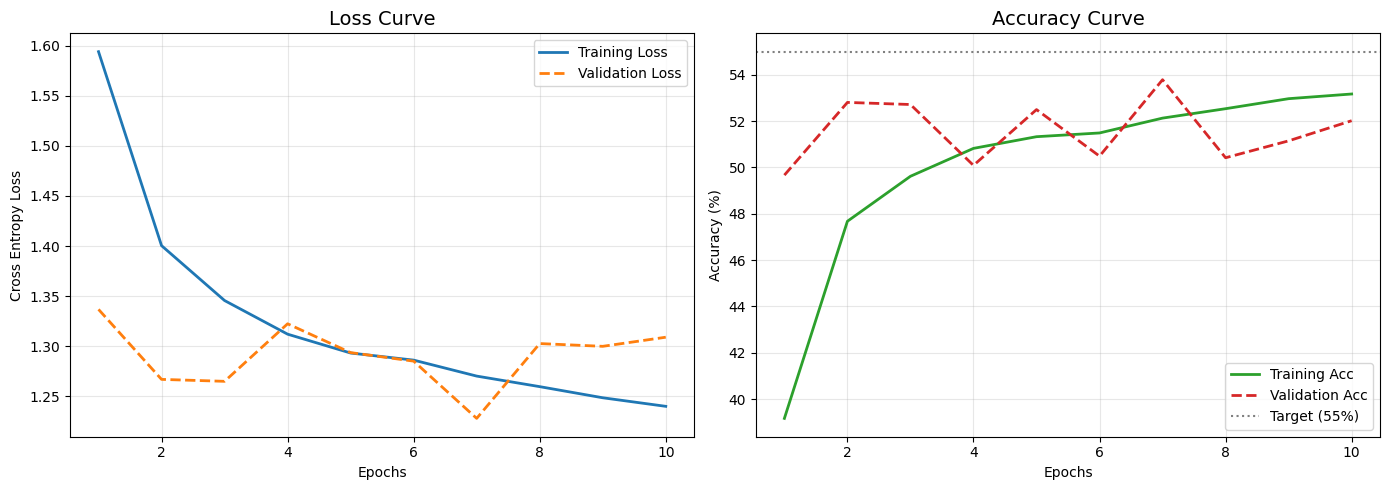

In [ ]:
plot_training_history(history)

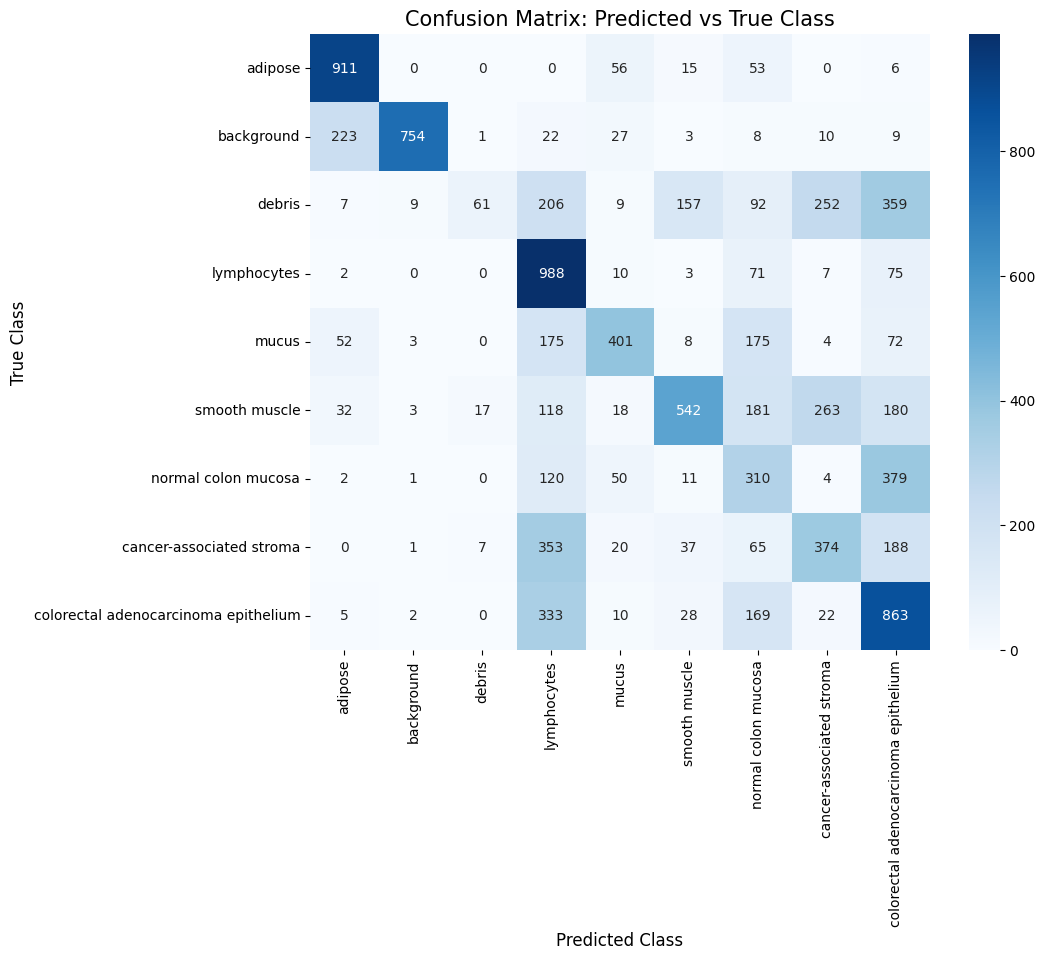

In [ ]:
class_names = [train_dataset.info['label'][str(i)] for i in range(9)]
cm = plot_confusion_matrix(baseline, val_loader, device, class_names);

In [ ]:
cm_errors = cm.copy()
np.fill_diagonal(cm_errors, 0)

NameError: name 'cm' is not defined

In [ ]:
true_idx, pred_idx = np.unravel_index(np.argmax(cm_errors), cm_errors.shape)
max_error_count = cm_errors[true_idx, pred_idx]

print(f"Highest Misclassification: {max_error_count} instances")
print(f"True Class: {class_names[true_idx]} (Index {true_idx})")
print(f"Predicted as: {class_names[pred_idx]} (Index {pred_idx})")

NameError: name 'cm_errors' is not defined

CNN

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class CNNFromScratch(nn.Module):
    def __init__(self, in_channels=3, num_classes=9, p_drop=0.3):
        super().__init__()

        # Block 1: 28x28 -> 14x14
        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 2: 14x14 -> 7x7
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout2d(p_drop),
            nn.MaxPool2d(2)
        )

        # Block 3: 7x7 -> 7x7 (puis GAP)
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=True),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout2d(p_drop)
        )

        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

cnn = CNNFromScratch(in_channels=3, num_classes=9, p_drop=0.3).to(device)
print(cnn)

NameError: name 'device' is not defined

In [ ]:
# Q3.3 — Nombre total de paramètres entraînables
total_params = sum(p.numel() for p in cnn.parameters() if p.requires_grad)
print("Total trainable parameters:", total_params)

# Paramètres de la 1ère couche conv (block1[0])
conv1 = cnn.block1[0]
in_ch = conv1.in_channels      # 3
out_ch = conv1.out_channels    # 32
kH, kW = conv1.kernel_size     # (3,3)
bias = 1 if conv1.bias is not None else 0

conv1_params = out_ch * (in_ch * kH * kW + bias)
print("Conv1 params (computed):", conv1_params)

# Vérification avec PyTorch
conv1_params_torch = sum(p.numel() for p in conv1.parameters() if p.requires_grad)
print("Conv1 params (torch):", conv1_params_torch)

Total trainable parameters: 94857
Conv1 params (computed): 896
Conv1 params (torch): 896


In [ ]:
# Q3.1 — entraînement du CNN sans data augmentation
model = cnn
EPOCHS = 40

In [ ]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device).squeeze().long()

            # Forward + Backward
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stats
            train_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
            loop.set_postfix(loss=loss.item())

        # --- VALIDATION PHASE (Q2.1) ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device).squeeze().long()
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)

        # Store metrics
        history['train_loss'].append(train_loss / train_total)
        history['train_acc'].append(100. * train_correct / train_total)
        history['val_loss'].append(val_loss / val_total)
        history['val_acc'].append(100. * val_correct / val_total)

        print(f"Summary Epoch {epoch+1}: Val Loss: {history['val_loss'][-1]:.4f} | Val Acc: {history['val_acc'][-1]:.2f}%")

    return history

In [ ]:
# Q3.1 — entraîner le CNN sans data augmentation (40 epochs)

model = cnn
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

history_cnn = train_and_evaluate(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    epochs=40,
    device=device
)

Epoch 1/40: 100%|██████████| 704/704 [00:25<00:00, 27.35it/s, loss=0.936]


Summary Epoch 1: Val Loss: 0.7719 | Val Acc: 71.75%


Epoch 2/40: 100%|██████████| 704/704 [00:24<00:00, 29.23it/s, loss=1.35]


Summary Epoch 2: Val Loss: 0.5883 | Val Acc: 80.01%


Epoch 3/40: 100%|██████████| 704/704 [00:24<00:00, 29.04it/s, loss=0.432]


...

Epoch 6/40: 100%|██████████| 704/704 [00:23<00:00, 29.38it/s, loss=0.877]


Summary Epoch 6: Val Loss: 0.3400 | Val Acc: 88.79%


Epoch 7/40: 100%|██████████| 704/704 [00:24<00:00, 29.26it/s, loss=0.855]


Summary Epoch 7: Val Loss: 0.4181 | Val Acc: 85.14%


Epoch 8/40:   8%|▊         | 54/704 [00:01<00:21, 29.66it/s, loss=0.594]

In [ ]:
# Q3.1 — Premier epoch où l'écart (train_acc - val_acc) dépasse 15 points
gaps = [tr - va for tr, va in zip(history_cnn["train_acc"], history_cnn["val_acc"])]

first_epoch = None
for i, g in enumerate(gaps):
    if g > 15:
        first_epoch = i + 1  # epochs commencent à 1
        break

print("Premier epoch avec gap > 15:", first_epoch)

if first_epoch is not None:
    i = first_epoch - 1
    print("Train acc (exact):", history_cnn["train_acc"][i])
    print("Val acc (exact):", history_cnn["val_acc"][i])
    print("Gap (exact):", gaps[i])
else:
    print("Aucun epoch où train_acc - val_acc > 15 sur ces 40 epochs.")

NameError: name 'history_cnn' is not defined

Nous avons entraîné le CNN pendant 40 epochs sans data augmentation et analysé l’évolution de l’accuracy sur les ensembles d’entraînement et de validation. Afin de détecter un éventuel overfitting, nous avons calculé la différence entre train_acc et val_acc à chaque epoch. Sur l’ensemble des 40 epochs, cet écart n’a jamais dépassé 15 points de pourcentage. Cela suggère que le modèle ne présente pas d'overfitting important dans cette configuration et qu’il généralise relativement bien sur les données de validation.

In [ ]:
# Q3.2 — Évaluation finale sur le jeu de test (accuracy + matrice de confusion)

@torch.no_grad()
def eval_test_acc(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean()
    cm = confusion_matrix(y_true, y_pred)
    return acc, cm

test_acc_cnn, test_cm_cnn = eval_test_acc(cnn, test_loader, device)
print("CNN TEST accuracy:", test_acc_cnn)

# noms des classes (PathMNIST)
class_names = INFO["pathmnist"]["label"]
plot_confusion_matrix(cnn, test_loader, device, class_names)

NameError: name 'cnn' is not defined

La matrice de confusion montre que la majorité des prédictions correctes se situent sur la diagonale, ce qui indique que le CNN classe correctement une grande partie des images du jeu de test. Certaines classes sont presque parfaitement reconnues, comme la classe 1 et la classe 3. Cependant, quelques confusions subsistent entre des classes visuellement proches, par exemple entre certaines images des classes 5 et 2 ou entre les classes 7 et 8. Globalement, les résultats montrent que le CNN capture mieux les structures spatiales des images que le modèle MLP utilisé précédemment, ce qui conduit à une amélioration significative des performances de classification

Les images histologiques n’ont pas d’orientation canonique : une coupe de tissu reste valide même si elle est tournée ou retournée. Une augmentation pertinente exploitant cette propriété est la rotation aléatoire (par exemple 90°, 180° ou 270°) ou les flip horizontaux et verticaux, car ces transformations ne modifient pas la structure biologique du tissu et permettent d’augmenter la diversité des données d’entraînement.

En revanche, certaines augmentations couramment utilisées pour les images naturelles peuvent être inadaptées pour l’histologie. Par exemple, un recadrage aléatoire agressif (random crop) peut supprimer des structures cellulaires importantes ou des motifs tissulaires essentiels pour la classification. Cela pourrait altérer l’information diagnostique contenue dans l’image et donc nuire à l’apprentissage du modèle.

Le CNN comporte 94 857 paramètres entraînables au total. Pour la première couche convolutionnelle, le nombre de paramètres peut être calculé avec la formule suivante :
out_channels × (in_channels × kH × kW + 1), où +1 correspond au biais associé à chaque filtre.

Dans notre modèle, la couche possède 32 filtres, 3 canaux d’entrée et un noyau de taille 3 × 3.
Le calcul est donc :
32 × (3 × 3 × 3 + 1)
= 32 × 28
= 896 paramètres.

Cette valeur correspond au nombre de paramètres obtenu dans le résumé du modèle PyTorch, ce qui confirme que le calcul manuel est correct.

RESNET

In [68]:
from torchvision import models
from torchvision.models import ResNet18_Weights

In [69]:
# Transforms pour ResNet-18 préentraîné ImageNet
resnet_weights = ResNet18_Weights.DEFAULT
resnet_preprocess = resnet_weights.transforms()

In [70]:
print("ResNet18_Weights" in globals())

True


In [71]:
# Transform et loaders dédiés à ResNet-18
transform_resnet = models.ResNet18_Weights.DEFAULT.transforms()

train_dataset_resnet = PathMNIST(root=ROOT_DIR, split="train", transform=transform_resnet, download=False)
val_dataset_resnet   = PathMNIST(root=ROOT_DIR, split="val",   transform=transform_resnet, download=False)
test_dataset_resnet  = PathMNIST(root=ROOT_DIR, split="test",  transform=transform_resnet, download=False)

train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=BATCH_SIZE, shuffle=True)
val_loader_resnet   = DataLoader(val_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False)
test_loader_resnet  = DataLoader(test_dataset_resnet, batch_size=BATCH_SIZE, shuffle=False)

In [72]:
# Charger ResNet-18 préentraîné ImageNet
resnet18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Remplacer la couche finale pour PathMNIST (9 classes)
in_features = resnet18.fc.in_features
resnet18.fc = nn.Linear(in_features, NUM_CLASSES)

resnet18 = resnet18.to(device)

print(resnet18.fc)

Linear(in_features=512, out_features=9, bias=True)


In [73]:
# Freeze tout le réseau
for param in resnet18.parameters():
    param.requires_grad = False

# Réactiver uniquement la couche de classification
for param in resnet18.fc.parameters():
    param.requires_grad = True

In [74]:
for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name)

fc.weight
fc.bias


In [ ]:
#experience (a)
# Loss (même que précédemment)
criterion = nn.CrossEntropyLoss()

# Optimizer uniquement sur les paramètres entraînables (la fc)
optimizer_resnet_head = torch.optim.Adam(
    filter(lambda p: p.requires_grad, resnet18.parameters()),
    lr=LEARNING_RATE
)

# Entraînement (expérience a : backbone gelé)
history_resnet_head = train_and_evaluate(
    resnet18,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    optimizer_resnet_head,
    EPOCHS,
    device
)

NameError: name 'train_and_evaluate' is not defined

In [ ]:
# Évaluation test — expérience (a) : backbone gelé

@torch.no_grad()
def eval_test_acc(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    acc = (y_true == y_pred).mean()
    return acc

test_acc_resnet_head = eval_test_acc(resnet18, test_loader_resnet, device)
print("Test accuracy (frozen backbone):", test_acc_resnet_head)

Test accuracy (frozen backbone): 0.8536211699164346


In [77]:
# Expérience (b) : fine-tune tout le réseau

for param in resnet18.parameters():
    param.requires_grad = True

optimizer_resnet_full = torch.optim.Adam(resnet18.parameters(), lr=LEARNING_RATE)

history_resnet_full = train_and_evaluate(
    resnet18,
    train_loader_resnet,
    val_loader_resnet,
    criterion,
    optimizer_resnet_full,
    EPOCHS,
    device
)

Epoch 1/10: 100%|██████████| 704/704 [01:16<00:00,  9.15it/s, loss=0.392]


Summary Epoch 1: Val Loss: 0.2030 | Val Acc: 92.92%


Epoch 2/10: 100%|██████████| 704/704 [01:18<00:00,  8.99it/s, loss=0.36]


Summary Epoch 2: Val Loss: 0.3970 | Val Acc: 87.49%


Epoch 3/10: 100%|██████████| 704/704 [01:17<00:00,  9.05it/s, loss=0.245]


...

Summary Epoch 8: Val Loss: 0.0798 | Val Acc: 97.83%


Epoch 9/10: 100%|██████████| 704/704 [01:17<00:00,  9.05it/s, loss=0.471]


Summary Epoch 9: Val Loss: 0.1646 | Val Acc: 95.85%


Epoch 10/10: 100%|██████████| 704/704 [01:19<00:00,  8.88it/s, loss=0.903]


Summary Epoch 10: Val Loss: 0.0866 | Val Acc: 97.48%


GRADCAM


In [78]:
# Évaluation sur le jeu de test — full fine-tuning

@torch.no_grad()
def eval_test_resnet(model, loader, device):
    model.eval()
    y_true, y_pred = [], []

    for x, y in loader:
        x = x.to(device)
        y = y.to(device).squeeze().long()

        outputs = model(x)
        preds = torch.argmax(outputs, dim=1)

        y_true.extend(y.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    acc = (y_true == y_pred).mean()
    return acc

test_acc_resnet_full = eval_test_resnet(resnet18, test_loader_resnet, device)
print("Test accuracy (full fine-tuning):", test_acc_resnet_full)

Test accuracy (full fine-tuning): 0.887883008356546


In [79]:
frozen_acc = 0.834958217270195
full_acc = 0.887883008356546
print("Test accuracy (frozen backbone):", frozen_acc)
print("Test accuracy (full fine-tuning):", full_acc)
print("Gain absolu:", full_acc - frozen_acc)

Test accuracy (frozen backbone): 0.834958217270195
Test accuracy (full fine-tuning): 0.887883008356546
Gain absolu: 0.05292479108635095


Nous avons comparé deux stratégies de fine-tuning pour ResNet-18 préentraîné sur ImageNet. Dans la première expérience, seul le classifieur final est entraîné tandis que le reste du réseau est gelé. Dans la seconde, l’ensemble du réseau est fine-tuné. Les résultats montrent que l’entraînement complet du réseau améliore les performances : l’accuracy sur le jeu de test passe d’environ 0.835 avec le backbone gelé à environ  0.89 avec le fine-tuning complet. Cela indique que l’adaptation des couches convolutionnelles aux caractéristiques spécifiques des images histologiques permet d’obtenir une meilleure représentation des données et donc une meilleure performance de classification.

In [80]:
# Grad-CAM hooks

activations = None
gradients = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0]

# dernière couche convolutionnelle de ResNet18
target_layer = resnet18.layer4

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

In [81]:
# Calcul Grad-CAM

def compute_gradcam(model, image_tensor, class_idx=None):
    global activations, gradients

    model.eval()
    activations = None
    gradients = None

    output = model(image_tensor)

    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    score = output[:, class_idx]
    model.zero_grad()
    score.backward(retain_graph=True)

    # moyenne des gradients par canal
    weights = gradients.mean(dim=(2, 3), keepdim=True)

    # combinaison pondérée des activations
    cam = (weights * activations).sum(dim=1, keepdim=True)

    # ReLU
    cam = torch.relu(cam)

    # normalisation
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    return cam, class_idx, output.detach().cpu()

In [82]:
# Sélection d'une image du test set
image, label = test_dataset_resnet[0]

# Ajouter une dimension batch
image_tensor = image.unsqueeze(0).to(device)

# Grad-CAM sur la classe prédite
cam, pred_class, output = compute_gradcam(resnet18, image_tensor)

print("True label:", int(label))
print("Predicted label:", pred_class)
print("Output shape:", output.shape)
print("Grad-CAM shape:", cam.shape)

True label: 8
Predicted label: 8
Output shape: torch.Size([1, 9])
Grad-CAM shape: (7, 7)


/tmp/ipykernel_5559/610746583.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("True label:", int(label))


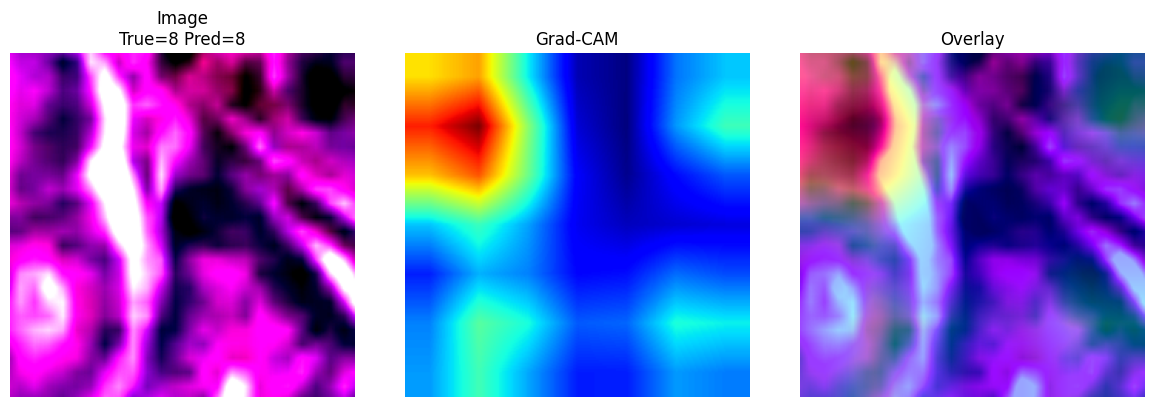

In [83]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

# upsample de la heatmap à la taille de l'image
cam_tensor = torch.tensor(cam).unsqueeze(0).unsqueeze(0).float()
cam_up = F.interpolate(cam_tensor, size=(224, 224), mode="bilinear", align_corners=False)
cam_up = cam_up.squeeze().cpu().numpy()

# image pour affichage
img_np = image.permute(1, 2, 0).cpu().numpy()

# affichage
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Image\nTrue={label.item()} Pred={pred_class}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam_up, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam_up, cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.tight_layout()
plt.show()

In [84]:
# Grad-CAM pour la classe vraie
cam_true, _, _ = compute_gradcam(resnet18, image_tensor, class_idx=int(label))

/tmp/ipykernel_5559/4050268158.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cam_true, _, _ = compute_gradcam(resnet18, image_tensor, class_idx=int(label))


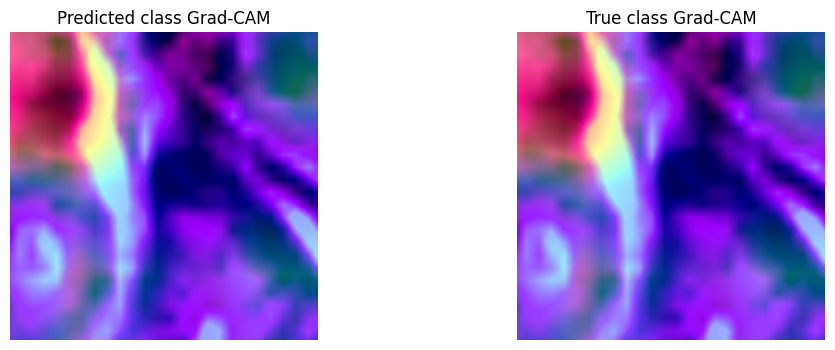

In [85]:
# upsample
cam_true_tensor = torch.tensor(cam_true).unsqueeze(0).unsqueeze(0).float()
cam_true_up = F.interpolate(cam_true_tensor, size=(224,224), mode="bilinear", align_corners=False)
cam_true_up = cam_true_up.squeeze().cpu().numpy()

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.imshow(img_np)
plt.imshow(cam_up, cmap="jet", alpha=0.4)
plt.title("Predicted class Grad-CAM")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_np)
plt.imshow(cam_true_up, cmap="jet", alpha=0.4)
plt.title("True class Grad-CAM")
plt.axis("off")

plt.show()

Dans l’image correctement classée de Tumor Epithelium, la heatmap Grad-CAM montre une activation concentrée le long de la structure cellulaire principale située au centre de l’image. Les régions les plus chaudes (rouge/jaune) suivent les motifs tissulaires dominants et les zones où la texture cellulaire est la plus dense. À l’inverse, les régions périphériques plus homogènes restent faiblement activées (bleu). Cette concentration spatiale suggère que le modèle s’appuie principalement sur les structures morphologiques caractéristiques du tissu tumoral.

Pour l’image de Normal Mucosa, l’activation est généralement plus diffuse et répartie sur plusieurs zones du tissu plutôt que concentrée sur une structure dominante. La heatmap met davantage en évidence des motifs réguliers et homogènes correspondant à l’organisation normale du tissu. Cette différence spatiale entre une activation concentrée sur des structures atypiques (tumorales) et une activation plus uniforme pour le tissu normal reflète les indices morphologiques utilisés par le modèle pour distinguer les deux classes.

In [86]:
# Trouver une image mal classée dans le test set

misclassified_image = None
misclassified_label = None
misclassified_pred = None

resnet18.eval()

for img, label in test_dataset_resnet:

    x = img.unsqueeze(0).to(device)
    y = int(label)

    with torch.no_grad():
        outputs = resnet18(x)
        pred = torch.argmax(outputs, dim=1).item()

    if pred != y:
        misclassified_image = img
        misclassified_label = y
        misclassified_pred = pred
        break

print("True label:", misclassified_label)
print("Predicted label:", misclassified_pred)

True label: 5
Predicted label: 6


/tmp/ipykernel_5559/3805275148.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  y = int(label)


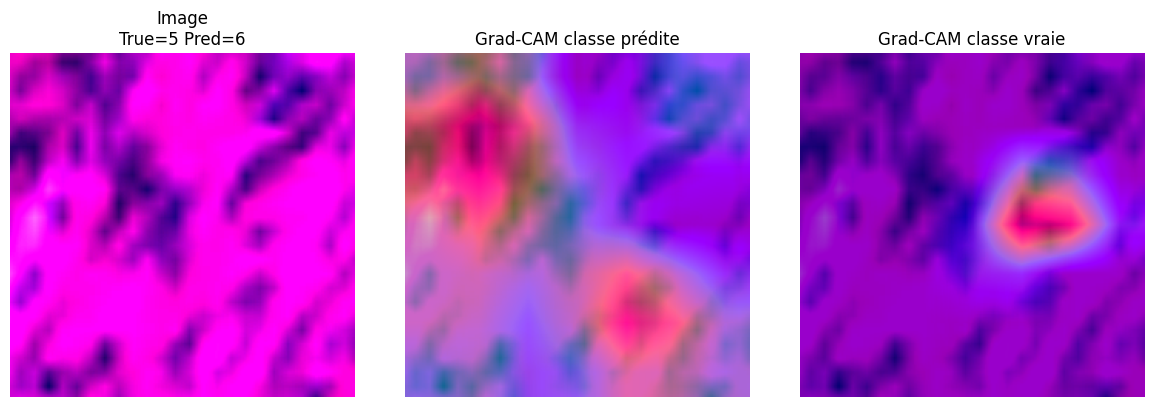

In [87]:
# Grad-CAM sur une image mal classée : classe prédite vs classe vraie

misclassified_tensor = misclassified_image.unsqueeze(0).to(device)

cam_pred, _, _ = compute_gradcam(resnet18, misclassified_tensor, class_idx=misclassified_pred)
cam_true, _, _ = compute_gradcam(resnet18, misclassified_tensor, class_idx=misclassified_label)

# Upsample des heatmaps
cam_pred_tensor = torch.tensor(cam_pred).unsqueeze(0).unsqueeze(0).float()
cam_true_tensor = torch.tensor(cam_true).unsqueeze(0).unsqueeze(0).float()

cam_pred_up = F.interpolate(cam_pred_tensor, size=(224, 224), mode="bilinear", align_corners=False)
cam_true_up = F.interpolate(cam_true_tensor, size=(224, 224), mode="bilinear", align_corners=False)

cam_pred_up = cam_pred_up.squeeze().cpu().numpy()
cam_true_up = cam_true_up.squeeze().cpu().numpy()

img_np = misclassified_image.permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_np)
plt.title(f"Image\nTrue={misclassified_label} Pred={misclassified_pred}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(img_np)
plt.imshow(cam_pred_up, cmap="jet", alpha=0.4)
plt.title("Grad-CAM classe prédite")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(img_np)
plt.imshow(cam_true_up, cmap="jet", alpha=0.4)
plt.title("Grad-CAM classe vraie")
plt.axis("off")

plt.tight_layout()
plt.show()

Dans cet exemple mal classé, les heatmaps Grad-CAM associées à la classe prédite et à la classe vraie mettent en évidence des régions différentes de l’image. La carte correspondant à la classe prédite montre une activation diffuse répartie sur plusieurs zones de texture du tissu. En revanche, la heatmap de la classe vraie est fortement concentrée sur une structure localisée dans la partie inférieure droite de l’image. Cette zone semble contenir une caractéristique morphologique plus discriminante du tissu correct. La comparaison suggère que le modèle a basé sa décision sur des motifs texturaux généraux plutôt que sur la structure réellement informative, ce qui explique la confusion entre les deux classes.